In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('dc_incidents.csv')
df.head()

,incident_id,date,time,server_id,location,incident_type,severity,downtime_minutes,technician,status,notes
0,INC001,2024-01-03,08:23,SRV-101,Rack A1,Power Failure,High,120,Ali Hassan,Resolved,UPS failed
1,INC002,2024-01-05,14:10,SRV-203,Rack B2,Network Outage,Medium,45,Priya Nair,Resolved,Switch malfunction
2,INC003,2024-01-07,NaN,SRV-305,Rack C1,Hardware Fault,High,200,Ali Hassan,Resolved,Disk failure
3,INC004,2024-01-10,09:00,SRV-101,Rack A1,Power Failure,High,150,NaN,NaN,Resolved
4,INC005,2024-01-12,11:30,SRV-410,Rack D2,Cooling Issue,Medium,60,Rajesh Kumar,Resolved,Temperature spike


In [2]:
print(df.shape)
print(df.info())

(50, 11)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   incident_id       50 non-null     str  
 1   date              50 non-null     str  
 2   time              46 non-null     str  
 3   server_id         46 non-null     str  
 4   location          50 non-null     str  
 5   incident_type     49 non-null     str  
 6   severity          50 non-null     str  
 7   downtime_minutes  49 non-null     str  
 8   technician        46 non-null     str  
 9   status            49 non-null     str  
 10  notes             18 non-null     str  
dtypes: str(11)
memory usage: 4.4 KB
None


In [3]:
df.isnull().sum()

incident_id          0
date                 0
time                 4
server_id            4
location             0
incident_type        1
severity             0
downtime_minutes     1
technician           4
status               1
notes               32
dtype: int64

In [4]:
df['severity'].unique()

<StringArray>
['High', 'Medium', 'LOW', 'Network Outage', 'HIGH', 'Low']
Length: 6, dtype: str

In [5]:
df['status'].unique()

<StringArray>
['Resolved', nan, 'resolved', 'Priya Nair', 'Pending']
Length: 5, dtype: str

In [6]:
df['location'].unique()

<StringArray>
['Rack A1', 'Rack B2', 'Rack C1', 'Rack D2', 'Rack E1', 'rack a1', 'SRV-203',
 'SRV-410', 'rack b2', 'rack c1', 'rack d2']
Length: 11, dtype: str

In [7]:
df['severity'] = df['severity'].str.title()

In [8]:
df['severity'].unique()

<StringArray>
['High', 'Medium', 'Low', 'Network Outage']
Length: 4, dtype: str

In [9]:
df['status'] = df['status'].str.title()
df['location'] = df['location'].str.title()

In [10]:
df['status'].unique()

<StringArray>
['Resolved', nan, 'Priya Nair', 'Pending']
Length: 4, dtype: str

In [11]:
df['location'].unique()

<StringArray>
['Rack A1', 'Rack B2', 'Rack C1', 'Rack D2', 'Rack E1', 'Srv-203', 'Srv-410']
Length: 7, dtype: str

In [12]:
import pandas as pd

df['severity'] = df['severity'].replace('Network Outage', pd.NA)
df['status'] = df['status'].replace('Priya Nair', pd.NA)
df['location'] = df['location'].replace(['Srv-203','Srv-410'], pd.NA)

In [13]:
print(df['severity'].unique())
print(df['status'].unique())
print(df['location'].unique())

<StringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str
<StringArray>
['Resolved', nan, 'Pending']
Length: 3, dtype: str
<StringArray>
['Rack A1', 'Rack B2', 'Rack C1', 'Rack D2', 'Rack E1', nan]
Length: 6, dtype: str


In [14]:
df['status'] = df['status'].fillna('Unknown')
df['severity'] = df['severity'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

In [15]:
print(df['status'].unique())
print(df['severity'].unique())
print(df['location'].unique())

<StringArray>
['Resolved', 'Unknown', 'Pending']
Length: 3, dtype: str
<StringArray>
['High', 'Medium', 'Low', 'Unknown']
Length: 4, dtype: str
<StringArray>
['Rack A1', 'Rack B2', 'Rack C1', 'Rack D2', 'Rack E1', 'Unknown']
Length: 6, dtype: str


In [16]:
df['technician'] = df['technician'].fillna('Unassigned')

In [17]:
df['technician'].unique()

<StringArray>
['Ali Hassan', 'Priya Nair', 'Unassigned', 'Rajesh Kumar', 'Siti Aminah',
 '50']
Length: 6, dtype: str

In [18]:
df['technician'] = df['technician'].replace('50', 'Unassigned')

In [19]:
df['technician'].unique()

<StringArray>
['Ali Hassan', 'Priya Nair', 'Unassigned', 'Rajesh Kumar', 'Siti Aminah']
Length: 5, dtype: str

In [20]:
df.isnull().sum()

incident_id          0
date                 0
time                 4
server_id            4
location             0
incident_type        1
severity             0
downtime_minutes     1
technician           0
status               0
notes               32
dtype: int64

In [21]:
df['time'] = df['time'].fillna('Unknown')
df['server_id'] = df['server_id'].fillna('Unknown')
df['incident_type'] = df['incident_type'].fillna('Unknown')
df['downtime_minutes'] = df['downtime_minutes'].fillna(0)

In [22]:
df.isnull().sum()

incident_id          0
date                 0
time                 0
server_id            0
location             0
incident_type        0
severity             0
downtime_minutes     0
technician           0
status               0
notes               32
dtype: int64

In [23]:
df.to_csv('dc_incidents_cleaned.csv', index = False)

In [24]:
df['incident_type'].value_counts()

incident_type
Power Failure     14
Hardware Fault    12
Network Outage    11
Cooling Issue     11
Rack B2            1
Unknown            1
Name: count, dtype: int64

In [25]:
df['incident_type'] = df['incident_type'].replace('Rack B2', 'Unknown')

In [26]:
df['incident_type'].value_counts()

incident_type
Power Failure     14
Hardware Fault    12
Network Outage    11
Cooling Issue     11
Unknown            2
Name: count, dtype: int64

In [28]:
df['downtime_minutes'] = pd.to_numeric(df['downtime_minutes'], errors='coerce')

In [29]:
df.groupby('server_id')['downtime_minutes'].sum().sort_values(ascending=False)

server_id
SRV-305    1928.0
SRV-101    1032.0
SRV-410     963.0
SRV-502     962.0
SRV-203     933.0
Unknown     138.0
Name: downtime_minutes, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

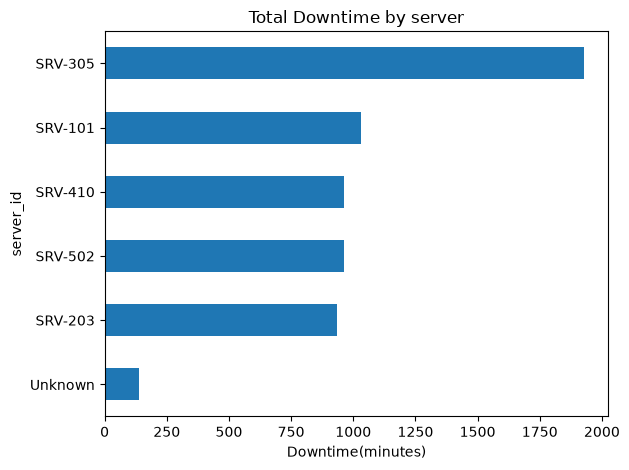

In [30]:
df.groupby('server_id')['downtime_minutes'].sum().sort_values().plot(kind='barh')
plt.title('Total Downtime by server')
plt.xlabel('Downtime(minutes)')
plt.tight_layout()
plt.show

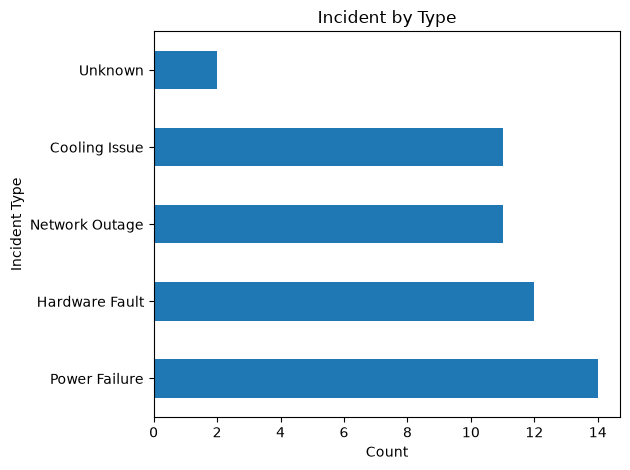

In [32]:
df['incident_type'].value_counts().plot(kind='barh')
plt.title('Incident by Type')
plt.xlabel('Count')
plt.ylabel('Incident Type')
plt.tight_layout()
plt.show()

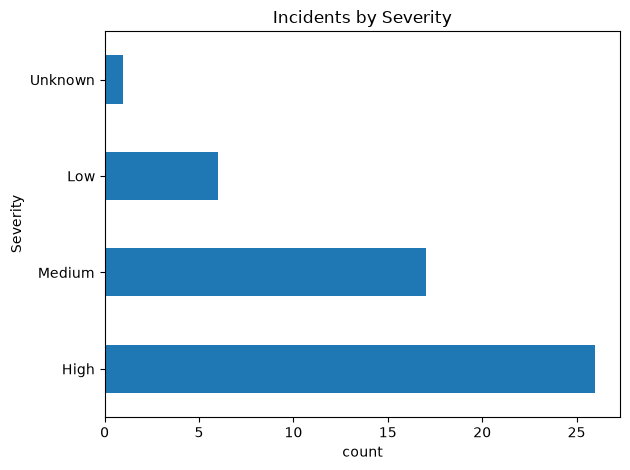

In [33]:
df['severity'].value_counts().plot(kind='barh')
plt.title('Incidents by Severity')
plt.xlabel('count')
plt.ylabel('Severity')
plt.tight_layout()
plt.show()

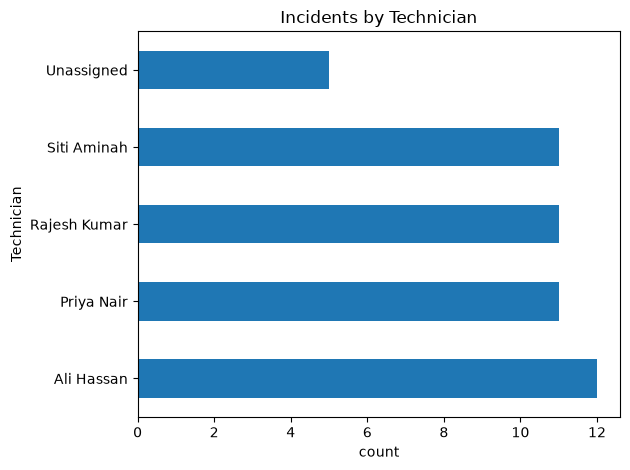

In [35]:
df['technician'].value_counts().plot(kind='barh')
plt.title('Incidents by Technician')
plt.xlabel('count')
plt.ylabel('Technician')
plt.tight_layout()
plt.show()